# Model Comparison

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/ML Assignment"
OUT_DIR = os.path.join(BASE_DIR, "final_comparison")
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


Load Results

In [2]:
PATHS = {
    "Logistic Regression": os.path.join(BASE_DIR, "logistic_regression", "logistic_regression_results.csv"),
    "Decision Tree":       os.path.join(BASE_DIR, "decision_tree", "decision_tree_results.csv"),
    "Random Forest":       os.path.join(BASE_DIR, "random_forest", "random_forest_results.csv"),
}
XGB_PATH = os.path.join(BASE_DIR, "xgboost", "xgboost_lifecycle_results.csv")

STAGES = ["Baseline Validation", "Tuned Validation", "Final Test"]
results = {}   # results[model] = DataFrame (rows = stages, columns = metrics)

# LR / DT / RF: rows = metrics, columns = stages
for model, path in PATHS.items():
    df = pd.read_csv(path, index_col=0).T
    results[model] = df.loc[STAGES]

# XGBoost: rows = stages. Falls back to the values you reported if the file is Model B's.
XGB_MODEL_A = pd.DataFrame({
    "Accuracy":        [0.4688, 0.4646, 0.4532],
    "Macro Precision": [0.4375, 0.4453, 0.4342],
    "Macro Recall":    [0.4444, 0.4460, 0.4342],
    "Macro F1":        [0.4385, 0.4440, 0.4331],
    "Weighted F1":     [0.4670, 0.4694, 0.4568],
    "ROC-AUC":         [0.6579, 0.6605, 0.6474],
}, index=STAGES)

if os.path.exists(XGB_PATH):
    x = pd.read_csv(XGB_PATH).set_index("Stage").loc[STAGES]
    # Make sure the file is Model A, not Model B (Model B test accuracy was 0.4729)
    if abs(x.loc["Final Test", "Accuracy"] - 0.4532) < 0.002:
        results["XGBoost"] = x
    else:
        print("WARNING: xgboost CSV is not Model A. Using the Model A values entered above.")
        results["XGBoost"] = XGB_MODEL_A
else:
    results["XGBoost"] = XGB_MODEL_A

MODEL_ORDER = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
METRICS = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "ROC-AUC"]

Combined Tables

In [3]:
def stage_table(stage):
    return pd.DataFrame({m: results[m].loc[stage, METRICS] for m in MODEL_ORDER}).T.round(4)

val_table  = stage_table("Tuned Validation")
test_table = stage_table("Final Test")
base_table = stage_table("Baseline Validation")

print("=== TUNED VALIDATION (used for model selection) ===")
display(val_table.sort_values("Macro F1", ascending=False))
print("\n=== FINAL TEST (reported once) ===")
display(test_table.sort_values("Macro F1", ascending=False))

=== TUNED VALIDATION (used for model selection) ===


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
Logistic Regression,0.4707,0.4732,0.4603,0.4599,0.4820,0.6647
Decision Tree,0.4678,0.4710,0.4580,0.4581,0.4792,0.6559
Random Forest,0.4641,0.4628,0.4558,0.4538,0.4746,0.6632
XGBoost,0.4646,0.4453,0.4460,0.4440,0.4694,0.6605



=== FINAL TEST (reported once) ===


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
Random Forest,0.4501,0.4506,0.4411,0.4405,0.4606,0.6503
Logistic Regression,0.4517,0.4505,0.4382,0.4394,0.4615,0.6525
Decision Tree,0.4483,0.4450,0.4324,0.4345,0.4571,0.6362
XGBoost,0.4532,0.4342,0.4342,0.4331,0.4568,0.6474


Model Selection on Validation Macro F1

In [4]:
best_model = val_table["Macro F1"].idxmax()
print(f"\nSelected model (highest validation Macro F1): {best_model}")
print(f"  Validation Macro F1 : {val_table.loc[best_model, 'Macro F1']:.4f}")
print(f"  Test Macro F1       : {test_table.loc[best_model, 'Macro F1']:.4f}")
print(f"  Test ROC-AUC        : {test_table.loc[best_model, 'ROC-AUC']:.4f}")


Selected model (highest validation Macro F1): Logistic Regression
  Validation Macro F1 : 0.4599
  Test Macro F1       : 0.4394
  Test ROC-AUC        : 0.6525


Validation VS Test Gap (generalisation check)

In [5]:
gap = pd.DataFrame({
    "Val Macro F1":  val_table["Macro F1"],
    "Test Macro F1": test_table["Macro F1"],
    "F1 Drop":       val_table["Macro F1"] - test_table["Macro F1"],
    "Val AUC":       val_table["ROC-AUC"],
    "Test AUC":      test_table["ROC-AUC"],
    "AUC Drop":      val_table["ROC-AUC"] - test_table["ROC-AUC"],
}).round(4)
display(gap)

,Val Macro F1,Test Macro F1,F1 Drop,Val AUC,Test AUC,AUC Drop
Logistic Regression,0.4599,0.4394,0.0205,0.6647,0.6525,0.0122
Decision Tree,0.4581,0.4345,0.0236,0.6559,0.6362,0.0197
Random Forest,0.4538,0.4405,0.0133,0.6632,0.6503,0.0129
XGBoost,0.4440,0.4331,0.0109,0.6605,0.6474,0.0131


Baseline (majority class) Reference

In [6]:
MAJORITY_ACC, MAJORITY_F1 = 0.4421, 0.2047   # test set: always predict Home Win
print(f"Majority-class baseline (test): accuracy {MAJORITY_ACC}, macro F1 about {MAJORITY_F1}")

Majority-class baseline (test): accuracy 0.4421, macro F1 about 0.2047


Charts

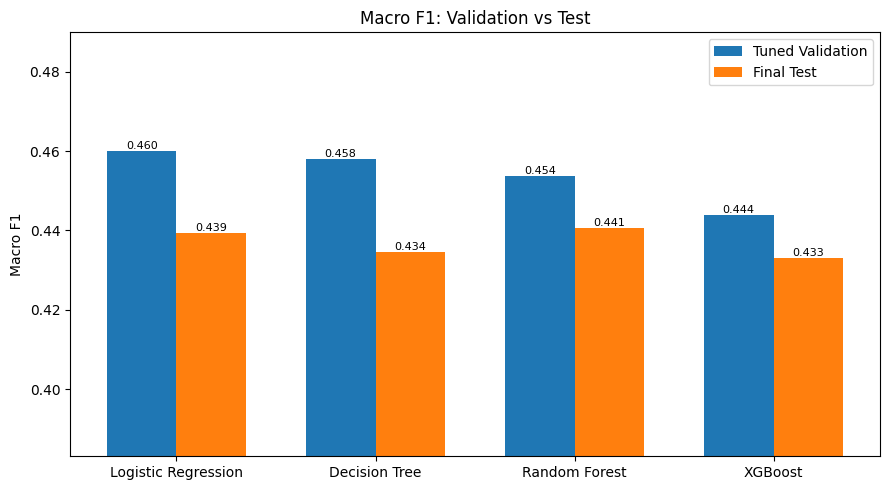

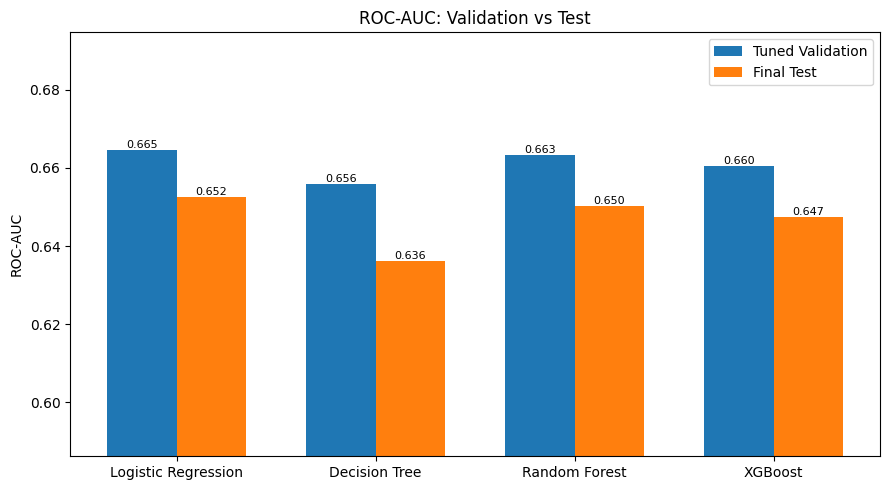

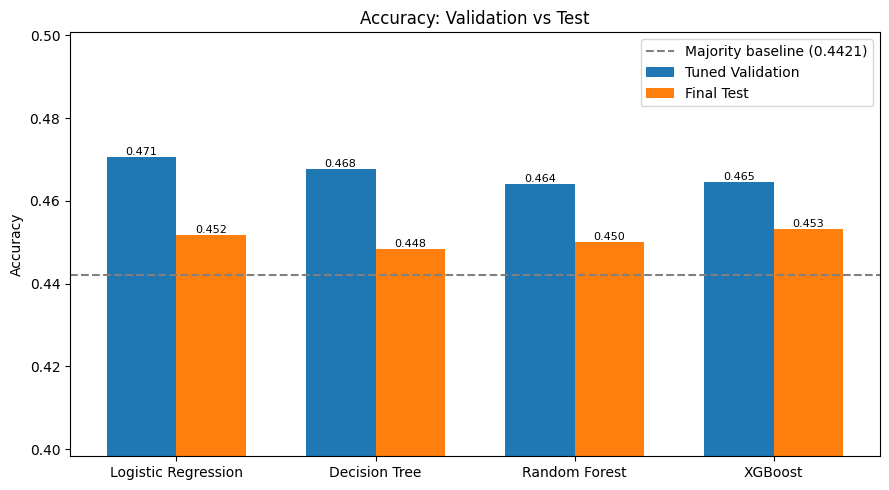

In [9]:
def grouped_bar(metric, fname, ref=None):
    x = np.arange(len(MODEL_ORDER)); w = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    v = ax.bar(x - w/2, val_table.loc[MODEL_ORDER, metric],  w, label="Tuned Validation")
    t = ax.bar(x + w/2, test_table.loc[MODEL_ORDER, metric], w, label="Final Test")
    ax.bar_label(v, fmt="%.3f", fontsize=8); ax.bar_label(t, fmt="%.3f", fontsize=8)
    if ref is not None:
        ax.axhline(ref, color="grey", linestyle="--", label=f"Majority baseline ({ref})")
    lo = min(val_table[metric].min(), test_table[metric].min())
    ax.set_ylim(max(0, lo - 0.05), max(val_table[metric].max(), test_table[metric].max()) + 0.03)
    ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylabel(metric); ax.set_title(f"{metric}: Validation vs Test")
    ax.legend(); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=300)
    plt.show()

grouped_bar("Macro F1", "comparison_macro_f1.png")
grouped_bar("ROC-AUC",  "comparison_roc_auc.png")
grouped_bar("Accuracy", "comparison_accuracy.png", ref=MAJORITY_ACC)

Save Outputs

In [8]:
val_table.to_csv(os.path.join(OUT_DIR, "comparison_validation.csv"))
test_table.to_csv(os.path.join(OUT_DIR, "comparison_test.csv"))
base_table.to_csv(os.path.join(OUT_DIR, "comparison_baseline_validation.csv"))
gap.to_csv(os.path.join(OUT_DIR, "comparison_generalisation_gap.csv"))
print("Saved to:", OUT_DIR)

Saved to: /content/drive/MyDrive/ML Assignment/final_comparison
